## Section 1: Environment Setup

### Step 1.1: Install Required Libraries



In [26]:
import torch
import timm

print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.6.0+cu124
timm: 1.0.25
GPU available: True


In [27]:

import pandas as pd
import numpy as np
import os
from collections import Counter
from tqdm import tqdm
import timm

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


## Section 2: Dataset Download and Setup

### Step 2.1: Verify Dataset Existence


In [28]:
import os

# Set the dataset path
DATA_DIR = "archive"  
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

# Verify the path
if os.path.exists(DATA_DIR):
    print(f" Dataset found at: {os.path.abspath(DATA_DIR)}")
    print(f" Metadata path: {METADATA_PATH}")
else:
    print(f" ERROR: Dataset not found at {DATA_DIR}")

 Dataset found at: /home/winterdark/Desktop/4-2/project_ham10000/archive
 Metadata path: archive/HAM10000_metadata.csv


## Section 3: Understanding Dataset

### Step 3.1: Basic Information

In [29]:
df = pd.read_csv(METADATA_PATH)
print(f"--Total images: {len(df)}")
print(f"--Unique lesions: {df['lesion_id'].nunique()}")
print(f"--Classes: {df['dx'].nunique()}")
display(df.head())

print("\n--Datatypes:--\n")
print(df.dtypes)

print(f"\n--Missing Values:--")
print(df.isnull().sum())

print(f"\n--Dataset Shape:--")
print(df.shape)

--Total images: 10015
--Unique lesions: 7470
--Classes: 7


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



--Datatypes:--

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

--Missing Values:--
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

--Dataset Shape:--
(10015, 7)


In [30]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


### Step 3.2: Missing Value Handling

In [31]:

df['age'].fillna(df['age'].mean(), inplace=True)
print(df.isnull().sum())

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


/tmp/ipykernel_6546/3585923041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


### Step 3.3: Class Distribution Analysis

In [32]:
# Get class counts
class_counts = df['dx'].value_counts()

# Class names (full descriptions)
class_names = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

print("\n--Class Distribution:--")

for cls in class_counts.index:
    count = class_counts[cls]
    percentage = (count / len(df)) * 100
    print(f"{cls:6s} -> {class_names[cls]:25s}: {count:5d} ({percentage:5.2f}%)")

print("\n--Imbalance Ratio:--")
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class
print(f"  Most common class: {class_counts.index[0]} ({max_class} images)")
print(f"  Least common class: {class_counts.index[-1]} ({min_class} images)")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")


--Class Distribution:--
nv     -> Melanocytic nevi         :  6705 (66.95%)
mel    -> Melanoma                 :  1113 (11.11%)
bkl    -> Benign keratosis         :  1099 (10.97%)
bcc    -> Basal cell carcinoma     :   514 ( 5.13%)
akiec  -> Actinic keratoses        :   327 ( 3.27%)
vasc   -> Vascular lesions         :   142 ( 1.42%)
df     -> Dermatofibroma           :   115 ( 1.15%)

--Imbalance Ratio:--
  Most common class: nv (6705 images)
  Least common class: df (115 images)
  Imbalance ratio: 58.30:1


### Step 3.4: Visualize Class Distribution

The dataset is highly imbalanced. 'nv' (Melanocytic nevi) dominates with approximately 67% of images and 'df' (Dermatofibroma) has only approximately 1% of images. In barchart and pie chart this is visible

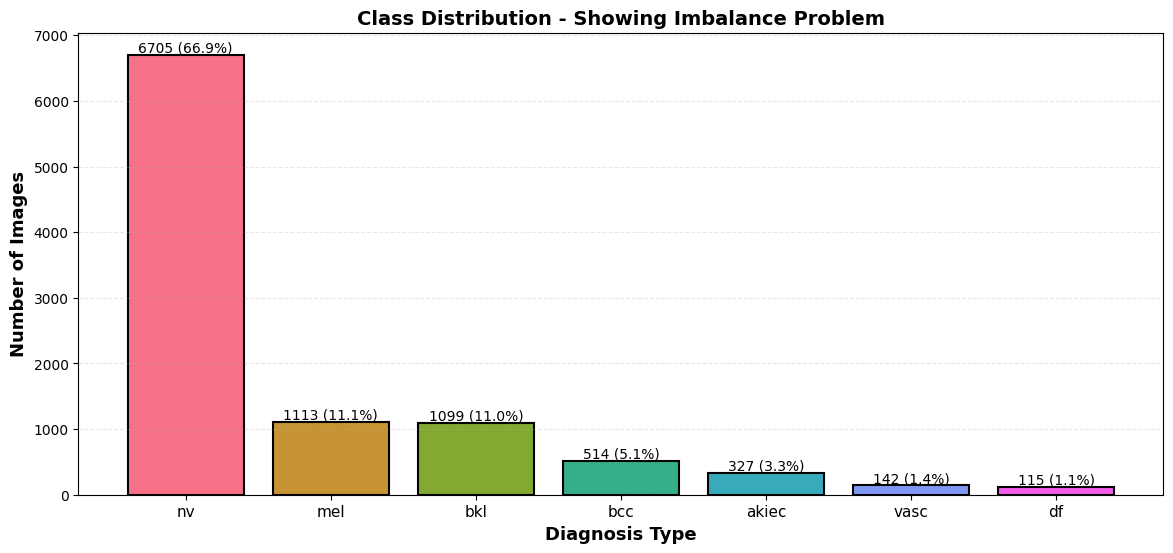

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))

colors = sns.color_palette("husl", len(class_counts))
bars = ax.bar(
    range(len(class_counts)),
    class_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax.set_xlabel('Diagnosis Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=13, fontweight='bold')
ax.set_title('Class Distribution - Showing Imbalance Problem', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, count in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{count} ({count/len(df)*100:.1f}%)',
        ha='center', va='bottom'
    )

plt.show()


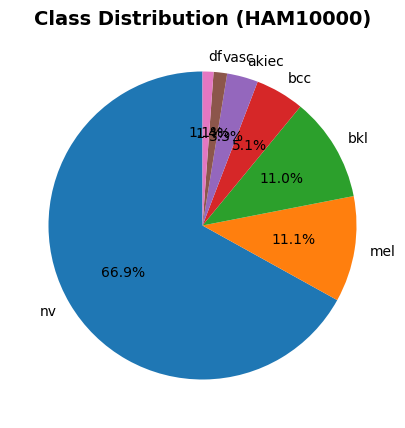

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Class Distribution (HAM10000)', fontsize=14, fontweight='bold')

plt.show()


## Section 4: Data Leakage Analysis

The dataset contains multiple images per lesion. Random splitting causes data leakage by placing images from the same lesion in different sets, affecting test accuracy.

In [35]:

# Count how many images each lesion has
images_per_lesion = df.groupby('lesion_id').size()

print(f"\n--Basic Statistics:--")
print(f"  - Total unique lesions: {len(images_per_lesion):,}")
print(f"  - Total images: {len(df):,}")
print(f"  - Mean images per lesion: {images_per_lesion.mean():.2f}")
print(f"  - Max images per lesion: {images_per_lesion.max()}")
print(f"  - Min images per lesion: {images_per_lesion.min()}")

# Distribution breakdown
print(f"\n--Distribution Breakdown:--")
single_image = (images_per_lesion == 1).sum()
multiple_images = (images_per_lesion > 1).sum()

single_image_percentage = single_image/len(images_per_lesion)*100
multiple_images_percentage = multiple_images/len(images_per_lesion)*100

print(f"  - Lesions with only 1 image: {single_image:,} ({single_image_percentage:.1f}%)")
print(f"  - Lesions with 2+ images: {multiple_images:,} ({multiple_images_percentage:.1f}%)")


print("\n--Quantifying The Data Leakage Risk:--")

total_images = len(df)
images_from_multi_lesions = total_images - single_image

print(f"  - Total images: {total_images:,}")
print(f"  - Images from lesions with 2+ photos: {images_from_multi_lesions:,}")
print(f"  - Percentage at risk: {images_from_multi_lesions/total_images*100:.1f}%")
print(f"\nThis means {images_from_multi_lesions/total_images*100:.1f}% of the dataset is at risk")



--Basic Statistics:--
  - Total unique lesions: 7,470
  - Total images: 10,015
  - Mean images per lesion: 1.34
  - Max images per lesion: 6
  - Min images per lesion: 1

--Distribution Breakdown:--
  - Lesions with only 1 image: 5,514 (73.8%)
  - Lesions with 2+ images: 1,956 (26.2%)

--Quantifying The Data Leakage Risk:--
  - Total images: 10,015
  - Images from lesions with 2+ photos: 4,501
  - Percentage at risk: 44.9%

This means 44.9% of the dataset is at risk


## Section 5: Data Preprocessing

Resize → Normalize → Split by lesion_id → Augment (train only) → Oversample (train only)
By splitting without looking at anything, it may happen that same lesion gets to both training and test dataset, which can leak information. so we've splitted by lesion_id. Then augment to make a robust dataset and oversample 
to remove the imbalance in dataset (nv - 6705, df - 115)

### Section 5.1: Resizing the images to 224 x 224

after resizing, saving this to disk, so that we dont have to process this huge dataset everytime.

In [36]:
from tqdm import tqdm

def resize_and_save_images(df):
    """
    Resize all images and save to disk.
    
    Args:
        df : DataFrame with 'image_id' column
    
    Returns:
        missing : List of image_ids that were not found
    """
    IMAGE_SIZE = (224, 224)
    IMAGE_DIRS = [
        'archive/HAM10000_images_part_1',
        'archive/HAM10000_images_part_2'
    ]
    OUTPUT_DIR = 'archive/HAM10000_resized'

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    saved   = 0
    missing = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Resizing"):
        out_path = os.path.join(OUTPUT_DIR, row['image_id'] + '.jpg')

        if os.path.exists(out_path):
            saved += 1
            continue

        for img_dir in IMAGE_DIRS:
            img_path = os.path.join(img_dir, row['image_id'] + '.jpg')
            if os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
                img = img.resize(IMAGE_SIZE)
                img.save(out_path, quality=95)
                saved += 1
                break
        else:
            missing.append(row['image_id'])

    print(f"\n--Summary--")
    print(f"  - Saved:   {saved:,}")
    print(f"  - Missing: {len(missing):,}")

    return missing

### Section 5.2: Compute HAM10000 own mean and standard deviation

In [37]:
import torch
from tqdm import tqdm
from torchvision import transforms

print("--Computing HAM10000 Mean & Std--")

def compute_mean_std(df):
    """
    Compute per-channel mean and std of resized images.
    
    Args:
        df : DataFrame with 'image_id' column
    
    Returns:
        mean : Tensor of shape [3]
        std  : Tensor of shape [3]
    """
    OUTPUT_DIR = 'archive/HAM10000_resized'

    to_tensor = transforms.Compose([
        transforms.ToTensor()
    ])

    channel_sum    = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    count = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Computing stats"):
        img_path = os.path.join(OUTPUT_DIR, row['image_id'] + '.jpg')
        img    = Image.open(img_path).convert('RGB')
        tensor = to_tensor(img)

        channel_sum    += tensor.sum(dim=[1, 2])
        channel_sq_sum += (tensor ** 2).sum(dim=[1, 2])
        count          += tensor.shape[1] * tensor.shape[2]

    mean = channel_sum / count
    std  = (channel_sq_sum / count - mean ** 2) ** 0.5

    print(f"\n--HAM10000 Dataset Statistics--")
    print(f"  - Mean: {mean.tolist()}")
    print(f"  - Std:  {std.tolist()}")

    return mean, std

--Computing HAM10000 Mean & Std--


### Section 5.3: Random Splitting

Split dataset randomly without considering lesion ID. 70% train, 15% val, 15% test. May cause data leakage — same lesion can appear in multiple splits.

In [38]:
def split_dataset_random(df):
    """
    Args:
        df : DataFrame with 'image_id' column
    
    Returns:
        train_df : Training DataFrame
        val_df   : Validation DataFrame
        test_df  : Test DataFrame
    """
    print("--Splitting Dataset Randomly (No Lesion ID Check)--")

    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
    val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=42)

    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

    print(f"\n--Split Summary--")
    print(f"  - Train images: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  - Val images:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  - Test images:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")
    print(f"  - Total:        {len(train_df)+len(val_df)+len(test_df):,}")

    return train_df, val_df, test_df

### Section 5.4: Spliting by lesion id

Split dataset by lesion ID to prevent data leakage. 70% train, 15% val, 15% test.

In [39]:
def split_dataset(df):
    """
    Args:
        df : DataFrame with 'lesion_id' and 'image_id' columns
    
    Returns:
        train_df : Training DataFrame
        val_df   : Validation DataFrame
        test_df  : Test DataFrame
    """
    print("--Splitting Dataset by Lesion ID--")

    unique_lesions = df['lesion_id'].unique()
    print(f"\n  - Total unique lesions: {len(unique_lesions):,}")

    train_lesions, temp_lesions = train_test_split(unique_lesions,
                                                    test_size=0.30,
                                                    random_state=42)
    val_lesions, test_lesions   = train_test_split(temp_lesions,
                                                    test_size=0.50,
                                                    random_state=42)

    train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
    val_df   = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
    test_df  = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

    print(f"\n--Split Summary--")
    print(f"  - Train images: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  - Val images:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  - Test images:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")
    print(f"  - Total:        {len(train_df)+len(val_df)+len(test_df):,}")

    # ── Leakage Check ──────────────────────────────────────────────────────────
    print(f"\n--Leakage Check--")
    train_lesion_set = set(train_df['lesion_id'])
    val_lesion_set   = set(val_df['lesion_id'])
    test_lesion_set  = set(test_df['lesion_id'])

    train_val_overlap  = train_lesion_set & val_lesion_set
    train_test_overlap = train_lesion_set & test_lesion_set
    val_test_overlap   = val_lesion_set   & test_lesion_set

    print(f"  - Train/Val overlap:  {len(train_val_overlap)}")
    print(f"  - Train/Test overlap: {len(train_test_overlap)}")
    print(f"  - Val/Test overlap:   {len(val_test_overlap)}")

    if len(train_val_overlap) == len(train_test_overlap) == len(val_test_overlap) == 0:
        print(f"\n  ✓ No leakage detected! Split is clean.")
    else:
        print(f"\n  ✗ Leakage detected! Something went wrong.")

    return train_df, val_df, test_df

### Section 5.5: Augmentation

These augmentations introduced variability by simulating different orientations, lighting conditions, and geometric
distortions, enriching the training set and helping the model learn robust, discriminative features. Sigmoid intensity correction used to enhance contrast as dermascopic images sometimes have low contrast, uneven lighting, faint lesion boundaries.

In [40]:

# ── Sigmoid Intensity Correction (custom, not in torchvision) ─────────────────
class SigmoidIntensityCorrection:
    def __init__(self, gain=10, cutoff=0.5):
        self.gain = gain          # empirically tuned
        self.cutoff = cutoff

    def __call__(self, img):
        img_array = np.array(img).astype(np.float32) / 255.0
        corrected = 1 / (1 + np.exp(-self.gain * (img_array - self.cutoff)))
        corrected = (corrected * 255).astype(np.uint8)
        return Image.fromarray(corrected)


In [41]:
import torchvision.transforms.functional as TF
import random
import math

def get_transforms(mean, std, use_augmentation=True):
    """
    Get train and val/test transforms.

    Args:
        mean             : Channel mean tensor from compute_mean_std()
        std              : Channel std tensor from compute_mean_std()
        use_augmentation : If True, apply augmentation to train transform

    Returns:
        train_transform     : Transform for training set
        val_test_transform  : Transform for val and test sets
    """
    IMAGE_SIZE = (224, 224)

    if use_augmentation:
        train_transform = transforms.Compose([
            transforms.RandomRotation(degrees=30),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.80, 1.0)),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2)),
            transforms.RandomAffine(degrees=0, shear=(-0.2, 0.2), scale=(0.8, 1.2)),
            SigmoidIntensityCorrection(gain=10, cutoff=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean.tolist(), std=std.tolist())
        ])
    else:
        train_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=mean.tolist(), std=std.tolist())
        ])

    val_test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean.tolist(), std=std.tolist())
    ])

    return train_transform, val_test_transform

### Section 5.6: Oversample

Oversample minority classes in training set to match majority class. HAM10000 is heavily imbalanced.

In [42]:
from collections import Counter

def oversample_training_data(train_df, val_df, test_df):
    """
    Args:
        train_df : Training DataFrame with 'dx' column
        val_df   : Validation DataFrame (used only for summary print)
        test_df  : Test DataFrame (used only for summary print)

    Returns:
        train_oversampled_df : Oversampled training DataFrame
    """
    print("--Class Distribution Before Oversampling--")
    class_counts = Counter(train_df['dx'])
    for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f"  - {cls}: {count:,}")

    max_count = max(class_counts.values())
    print(f"\n  - Target count per class: {max_count:,}")

    oversampled_dfs = []

    for cls in class_counts:
        cls_df    = train_df[train_df['dx'] == cls]
        cls_count = len(cls_df)

        if cls_count < max_count:
            oversampled = cls_df.sample(
                n=max_count - cls_count,
                replace=True,
                random_state=42
            )
            oversampled_dfs.append(cls_df)
            oversampled_dfs.append(oversampled)
        else:
            oversampled_dfs.append(cls_df)

    train_oversampled_df = pd.concat(oversampled_dfs).reset_index(drop=True)

    print("\n--Class Distribution After Oversampling--")
    new_counts = Counter(train_oversampled_df['dx'])
    for cls, count in sorted(new_counts.items(), key=lambda x: -x[1]):
        print(f"  - {cls}: {count:,}")

    print(f"\n--Oversampling Summary--")
    print(f"  - Train images before: {len(train_df):,}")
    print(f"  - Train images after:  {len(train_oversampled_df):,}")
    print(f"  - Val images:          {len(val_df):,}  (unchanged)")
    print(f"  - Test images:         {len(test_df):,}  (unchanged)")

    return train_oversampled_df

### Section 5.6: Creating dataloader


In [43]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

label_map = {
    'nv'   : 0,
    'mel'  : 1,
    'bkl'  : 2,
    'bcc'  : 3,
    'akiec': 4,
    'df'   : 5,
    'vasc' : 6
}

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.img_dir   = 'archive/HAM10000_resized'
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'] + '.jpg')
        img      = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        label = label_map[row['dx']]
        return img, label


def get_dataloaders(train_df, val_df, test_df, train_transform, val_test_transform, batch_size=32):
    """
    Create datasets and dataloaders.

    Args:
        train_df            : Training DataFrame (already oversampled if needed)
        val_df              : Validation DataFrame
        test_df             : Test DataFrame
        train_transform     : Transform for training set
        val_test_transform  : Transform for val and test sets
        batch_size          : Batch size, default 32

    Returns:
        train_loader : Training DataLoader
        val_loader   : Validation DataLoader
        test_loader  : Test DataLoader
    """
    train_dataset = HAMDataset(train_df, transform=train_transform)
    val_dataset   = HAMDataset(val_df,   transform=val_test_transform)
    test_dataset  = HAMDataset(test_df,  transform=val_test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

    print("--Dataset Summary--")
    print(f"  - Train samples: {len(train_dataset):,}")
    print(f"  - Val samples:   {len(val_dataset):,}")
    print(f"  - Test samples:  {len(test_dataset):,}")

    print("\n--Dataloader Summary--")
    print(f"  - Train batches: {len(train_loader):,}")
    print(f"  - Val batches:   {len(val_loader):,}")
    print(f"  - Test batches:  {len(test_loader):,}")

    print("\n--Verifying 1 batch--")
    images, labels = next(iter(train_loader))
    print(f"  - Image batch shape: {images.shape}")
    print(f"  - Label batch shape: {labels.shape}")
    print(f"  - Label samples:     {labels[:5].tolist()}")
    print(f"  - Min pixel value:   {images.min():.4f}")
    print(f"  - Max pixel value:   {images.max():.4f}")

    return train_loader, val_loader, test_loader

## Section 6: Training


In [44]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
 
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
 
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
 
    return total_loss / total, correct / total

In [45]:
import timm

def get_model():
    """Load pretrained LeViT-256 and replace classifier head for 7 classes."""
    model = timm.create_model('levit_256', pretrained=True, num_classes=7)
    model = model.to(DEVICE)
    return model

In [46]:
from sklearn.metrics import f1_score, roc_auc_score

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
 
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
 
            outputs = model(images)
            loss    = criterion(outputs, labels)
            probs   = torch.softmax(outputs, dim=1)
 
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
 
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
 
    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average='weighted')
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
 
    return avg_loss, accuracy, f1, auc, all_preds, all_labels

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(train_loader, val_loader, num_epochs=20, lr=1e-4):
    """
    Full training loop with:
      - Phase 1: Freeze backbone, train head only (5 epochs)
      - Phase 2: Unfreeze all, fine-tune end-to-end (remaining epochs)
    """
    model     = get_model()
    criterion = nn.CrossEntropyLoss()
 
    # ── Phase 1: Freeze backbone ───────────────────────────────────────────────
    print("\n  [Phase 1] Training classifier head only...")
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True
 
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
 
    for epoch in range(5):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_auc, _, _ = evaluate(model, val_loader, criterion)
        print(f"  Epoch [{epoch+1}/5]  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")
 
    # ── Phase 2: Unfreeze all ──────────────────────────────────────────────────
    print("\n  [Phase 2] Fine-tuning full model...")
    for param in model.parameters():
        param.requires_grad = True
 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - 5)
 
    best_val_f1  = 0
    best_weights = None
 
    for epoch in range(num_epochs - 5):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
 
        print(f"  Epoch [{epoch+1}/{num_epochs-5}]  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
              f"Val F1: {val_f1:.4f}")
 
        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = model.state_dict().copy()
 
    # Load best weights
    model.load_state_dict(best_weights)
    return model

In [48]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [49]:
import time

def run_ablation_study(df, mean, std, num_epochs=20):
    experiments = [
        # (exp_name,                        split,    aug,   over)
        ("Random | No Aug | No Over",       "random", False, False),
        ("Random | Aug    | No Over",       "random", True,  False),
        ("Random | No Aug | Over",          "random", False, True ),
        ("Random | Aug    | Over",          "random", True,  True ),
        ("Lesion | No Aug | No Over",       "lesion", False, False),
        ("Lesion | Aug    | No Over",       "lesion", True,  False),
        ("Lesion | No Aug | Over",          "lesion", False, True ),
        ("Lesion | Aug    | Over  ← FULL",  "lesion", True,  True ),
    ]

    results   = []
    criterion = nn.CrossEntropyLoss()

    for exp_name, split, use_aug, use_over in experiments:
        print(f"\n>>> Running: {exp_name}")
        set_seed(42)

        # Split
        if split == "lesion":
            train_df, val_df, test_df = split_dataset(df)
        else:
            train_df, val_df, test_df = split_dataset_random(df)

        # Oversampling
        final_train_df = oversample_training_data(train_df, val_df, test_df) if use_over else train_df

        # Transforms & Dataloaders
        train_transform, val_test_transform = get_transforms(mean, std, use_augmentation=use_aug)
        train_loader, val_loader, test_loader = get_dataloaders(
            final_train_df, val_df, test_df,
            train_transform, val_test_transform
        )

        # Train & Evaluate
        start = time.time()
        model = train_model(train_loader, val_loader, num_epochs=num_epochs)
        elapsed = time.time() - start

        _, test_acc, test_f1, test_auc, _, _ = evaluate(model, test_loader, criterion)

        results.append({
            'Experiment'  : exp_name,
            'Split'       : 'Lesion-wise' if split == 'lesion' else 'Random',
            'Augmentation': '✓' if use_aug  else '✗',
            'Oversampling': '✓' if use_over else '✗',
            'Accuracy'    : round(test_acc, 4),
            'F1'          : round(test_f1,  4),
            'AUC'         : round(test_auc, 4),
            'Time (min)'  : round(elapsed / 60, 1)
        })

    # ── Final Results Table ────────────────────────────────────────────────────
    results_df = pd.DataFrame(results)

    print("\n")
    print("=" * 80)
    print("  ABLATION STUDY RESULTS")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("=" * 80)

    results_df.to_csv('ablation_results.csv', index=False)
    print("\n  ✓ Saved to ablation_results.csv")

    return results_df

In [50]:
# Step 1: Load metadata
df = pd.read_csv('archive/HAM10000_metadata.csv')
print(f"  - Total images: {len(df):,}")

# Step 2: Resize & save images
missing = resize_and_save_images(df)

# Step 3: Compute mean & std
mean, std = compute_mean_std(df)

# Step 4: Run ablation study (runs all 8 experiments & prints final table)
results_df = run_ablation_study(df, mean, std, num_epochs=20)

  - Total images: 10,015


Resizing: 100%|██████████| 10015/10015 [00:00<00:00, 15516.51it/s]



--Summary--
  - Saved:   10,015
  - Missing: 0


Computing stats: 100%|██████████| 10015/10015 [00:18<00:00, 533.47it/s]


--HAM10000 Dataset Statistics--
  - Mean: [0.7634178400039673, 0.5461365580558777, 0.5705513954162598]
  - Std:  [0.14088140428066254, 0.15229512751102448, 0.169362872838974]

>>> Running: Random | No Aug | No Over
--Splitting Dataset Randomly (No Lesion ID Check)--

--Split Summary--
  - Train images: 7,010 (70.0%)
  - Val images:   1,502 (15.0%)
  - Test images:  1,503 (15.0%)
  - Total:        10,015
--Dataset Summary--
  - Train samples: 7,010
  - Val samples:   1,502
  - Test samples:  1,503

--Dataloader Summary--
  - Train batches: 220
  - Val batches:   47
  - Test batches:  47

--Verifying 1 batch--


  - Image batch shape: torch.Size([32, 3, 224, 224])
  - Label batch shape: torch.Size([32])
  - Label samples:     [1, 0, 0, 2, 0]
  - Min pixel value:   -5.3075
  - Max pixel value:   2.9287

  [Phase 1] Training classifier head only...
  Epoch [1/5]  Train Loss: 1.1560  Train Acc: 0.6442  Val Loss: 1.3208  Val Acc: 0.6897
  Epoch [2/5]  Train Loss: 0.8014  Train Acc: 0.7181  Val Loss: 1.1974  Val Acc: 0.7150
  Epoch [3/5]  Train Loss: 0.7367  Train Acc: 0.7328  Val Loss: 1.0576  Val Acc: 0.7310
  Epoch [4/5]  Train Loss: 0.7030  Train Acc: 0.7512  Val Loss: 1.4379  Val Acc: 0.7290
  Epoch [5/5]  Train Loss: 0.6678  Train Acc: 0.7596  Val Loss: 1.7711  Val Acc: 0.7377

  [Phase 2] Fine-tuning full model...
  Epoch [1/15]  Train Loss: 0.6364  Train Acc: 0.7709  Val Loss: 1.3824  Val Acc: 0.7710  Val F1: 0.7525
  Epoch [2/15]  Train Loss: 0.5706  Train Acc: 0.7989  Val Loss: 1.6593  Val Acc: 0.7750  Val F1: 0.7588
  Epoch [3/15]  Train Loss: 0.5430  Train Acc: 0.8013  Val Loss: 0.9969 